# Carga de datos y features por ventanas

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

PROJECT = Path.home() / "Documents" / "rinde-soja"
df = pd.read_csv(PROJECT / "data" / "processed" / "dataset_modelado_soja.csv")

# Columnas que NO son features
META_COLS = ["campana", "partido", "rinde_qq_ha", "superficie_sembrada_ha", "superficie_cosechada_ha"]

# Ventanas temporales (acumulativas)
VENTANAS = ["oct_nov", "oct_dic", "oct_ene", "oct_feb", "oct_mar"]

def get_features_ventana(ventana):
    """Retorna las features disponibles hasta esa ventana."""
    idx = VENTANAS.index(ventana)
    ventanas_disponibles = VENTANAS[:idx+1]
    return [c for c in df.columns if c not in META_COLS
            and any(c.endswith(v) for v in ventanas_disponibles)]

print(f"Dataset: {df.shape}")
for v in VENTANAS:
    print(f"  {v}: {len(get_features_ventana(v))} features")

Dataset: (125, 70)
  oct_nov: 13 features
  oct_dic: 26 features
  oct_ene: 39 features
  oct_feb: 52 features
  oct_mar: 65 features


# Función de validación temporal walk-forward:

In [2]:
PRIMER_TEST = 2016  # Entrena 2000-2015, predice 2016, expande y repite

def walk_forward_evaluate(model_class, model_params, features):
    """Entrena expandiendo la ventana, predice 1 campaña a la vez."""
    resultados = []

    for test_year in range(PRIMER_TEST, 2025):
        train = df[df["campana"] < test_year]
        test = df[df["campana"] == test_year]
        if len(test) == 0:
            continue

        scaler = StandardScaler()
        X_train = scaler.fit_transform(train[features])
        X_test = scaler.transform(test[features])
        y_train = train["rinde_qq_ha"].values
        y_test = test["rinde_qq_ha"].values

        model = model_class(**model_params)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        for i in range(len(test)):
            resultados.append({
                "campana": test_year,
                "partido": test.iloc[i]["partido"],
                "rinde_real": y_test[i],
                "rinde_pred": y_pred[i],
            })

    return pd.DataFrame(resultados)

print("Función de validación definida")
print(f"Campañas de test: {PRIMER_TEST}-2024 ({2024-PRIMER_TEST+1} campañas × 5 partidos = {(2024-PRIMER_TEST+1)*5} predicciones)")

Función de validación definida
Campañas de test: 2016-2024 (9 campañas × 5 partidos = 45 predicciones)


# Entrenamiento de modelos y comparación

In [3]:
MODELOS = {
    "Regresión Lineal": (LinearRegression, {}),
    "Random Forest": (RandomForestRegressor, {"n_estimators": 100, "max_depth": 5, "random_state": 42}),
    "Gradient Boosting": (GradientBoostingRegressor, {"n_estimators": 100, "max_depth": 3, "learning_rate": 0.1, "random_state": 42}),
}

all_results = []
all_preds = {}  # Guardar predicciones para gráficos

for ventana in VENTANAS:
    features = get_features_ventana(ventana)
    all_preds[ventana] = {}

    for nombre, (model_class, params) in MODELOS.items():
        preds = walk_forward_evaluate(model_class, params, features)

        mae = mean_absolute_error(preds["rinde_real"], preds["rinde_pred"])
        rmse = np.sqrt(mean_squared_error(preds["rinde_real"], preds["rinde_pred"]))
        r2 = r2_score(preds["rinde_real"], preds["rinde_pred"])

        all_results.append({
            "ventana": ventana, "modelo": nombre,
            "MAE": round(mae, 2), "RMSE": round(rmse, 2), "R2": round(r2, 3),
            "n_features": len(features),
        })
        all_preds[ventana][nombre] = preds

results_df = pd.DataFrame(all_results)

# Mostrar tabla completa
for ventana in VENTANAS:
    print(f"\n--- {ventana.upper()} ---")
    sub = results_df[results_df["ventana"] == ventana]
    for _, row in sub.iterrows():
        print(f"  {row['modelo']:25s} | MAE: {row['MAE']:5.2f} | RMSE: {row['RMSE']:5.2f} | R²: {row['R2']:6.3f}")


--- OCT_NOV ---
  Regresión Lineal          | MAE:  4.73 | RMSE:  6.04 | R²: -0.008
  Random Forest             | MAE:  3.50 | RMSE:  4.45 | R²:  0.452
  Gradient Boosting         | MAE:  3.94 | RMSE:  4.99 | R²:  0.311

--- OCT_DIC ---
  Regresión Lineal          | MAE:  3.75 | RMSE:  4.65 | R²:  0.402
  Random Forest             | MAE:  3.46 | RMSE:  4.34 | R²:  0.478
  Gradient Boosting         | MAE:  3.75 | RMSE:  4.95 | R²:  0.321

--- OCT_ENE ---
  Regresión Lineal          | MAE:  4.78 | RMSE:  6.51 | R²: -0.171
  Random Forest             | MAE:  2.68 | RMSE:  3.41 | R²:  0.679
  Gradient Boosting         | MAE:  3.05 | RMSE:  3.82 | R²:  0.597

--- OCT_FEB ---
  Regresión Lineal          | MAE:  6.48 | RMSE:  9.61 | R²: -1.552
  Random Forest             | MAE:  2.74 | RMSE:  3.47 | R²:  0.668
  Gradient Boosting         | MAE:  2.82 | RMSE:  3.60 | R²:  0.641

--- OCT_MAR ---
  Regresión Lineal          | MAE:  7.38 | RMSE:  9.08 | R²: -1.281
  Random Forest             | M

# Mejor modelo por ventana

In [4]:
print("MEJOR MODELO POR VENTANA (menor MAE)")
print("=" * 60)
for ventana in VENTANAS:
    sub = results_df[results_df["ventana"] == ventana]
    best = sub.loc[sub["MAE"].idxmin()]
    print(f"  {ventana:10s} → {best['modelo']:25s} | MAE: {best['MAE']:.2f} qq/ha | R²: {best['R2']:.3f}")

MEJOR MODELO POR VENTANA (menor MAE)
  oct_nov    → Random Forest             | MAE: 3.50 qq/ha | R²: 0.452
  oct_dic    → Random Forest             | MAE: 3.46 qq/ha | R²: 0.478
  oct_ene    → Random Forest             | MAE: 2.68 qq/ha | R²: 0.679
  oct_feb    → Random Forest             | MAE: 2.74 qq/ha | R²: 0.668
  oct_mar    → Random Forest             | MAE: 2.68 qq/ha | R²: 0.659


# Gráfico 1: curva de error vs anticipación:

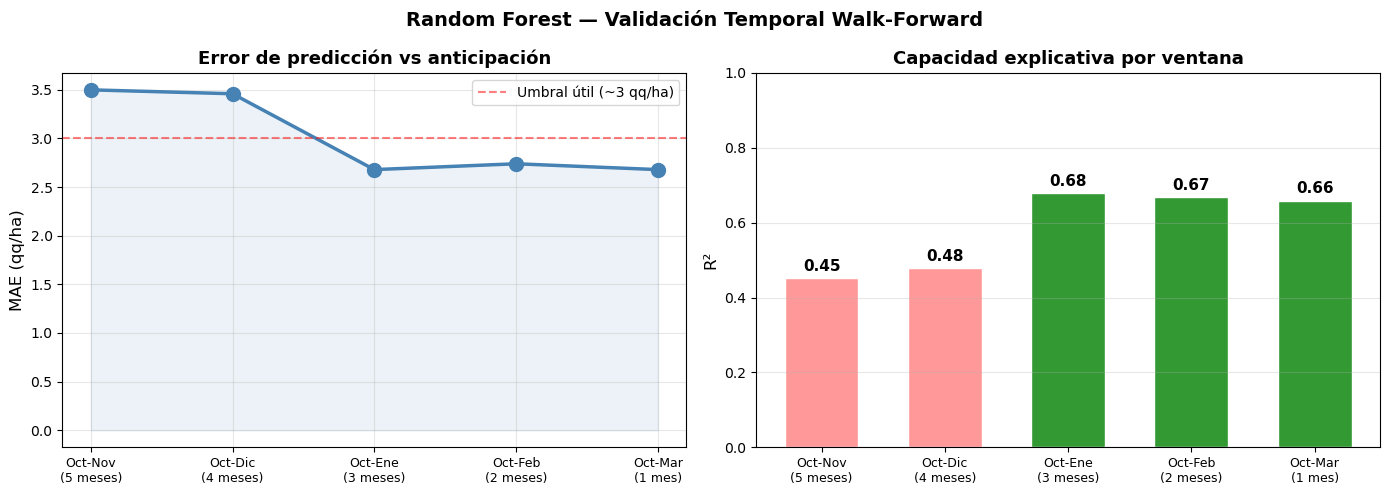

In [5]:
# Métricas de Random Forest por ventana (mejor modelo)
rf_metrics = results_df[results_df["modelo"] == "Random Forest"].reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels_x = ["Oct-Nov\n(5 meses)", "Oct-Dic\n(4 meses)", "Oct-Ene\n(3 meses)", "Oct-Feb\n(2 meses)", "Oct-Mar\n(1 mes)"]

# MAE por ventana
ax = axes[0]
ax.plot(range(5), rf_metrics["MAE"], marker="o", linewidth=2.5, color="steelblue", markersize=10)
ax.fill_between(range(5), 0, rf_metrics["MAE"], alpha=0.1, color="steelblue")
ax.axhline(y=3, color="red", linestyle="--", alpha=0.5, label="Umbral útil (~3 qq/ha)")
ax.set_xticks(range(5))
ax.set_xticklabels(labels_x, fontsize=9)
ax.set_ylabel("MAE (qq/ha)", fontsize=12)
ax.set_title("Error de predicción vs anticipación", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)

# R² por ventana
ax = axes[1]
colors = ["#ff9999" if r < 0.5 else "#99cc99" if r < 0.65 else "#339933" for r in rf_metrics["R2"]]
ax.bar(range(5), rf_metrics["R2"], color=colors, edgecolor="white", width=0.6)
ax.set_xticks(range(5))
ax.set_xticklabels(labels_x, fontsize=9)
ax.set_ylabel("R²", fontsize=12)
ax.set_title("Capacidad explicativa por ventana", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis="y")
for i, r2 in enumerate(rf_metrics["R2"]):
    ax.text(i, r2 + 0.02, f"{r2:.2f}", ha="center", fontsize=11, fontweight="bold")

plt.suptitle("Random Forest — Validación Temporal Walk-Forward", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Gráfico 2: predicción vs real y serie temporal (ventana oct_ene):

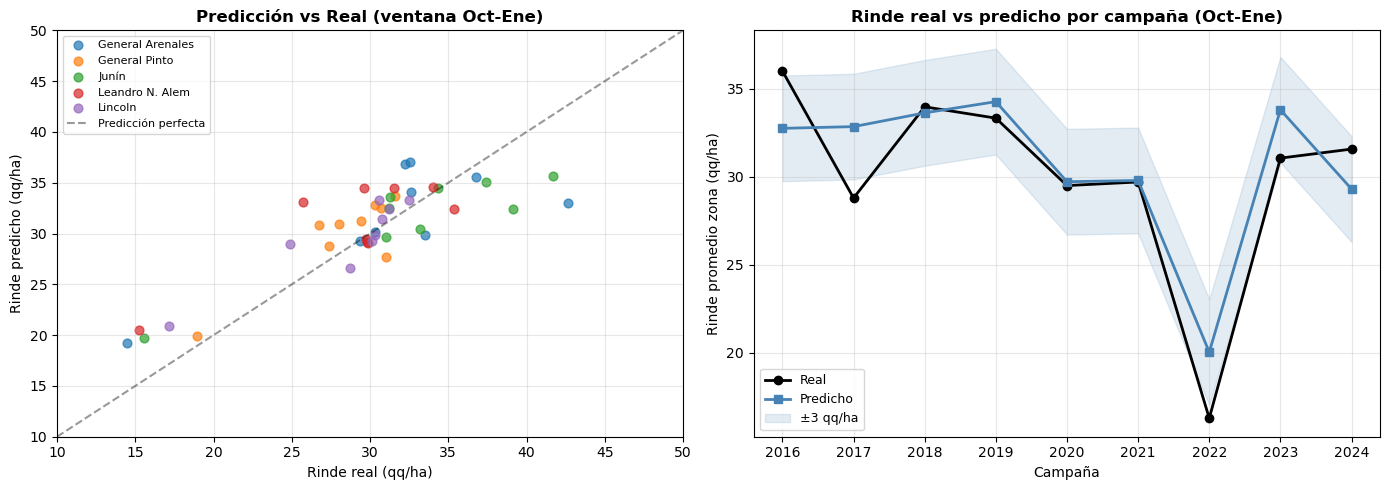

In [6]:
preds_ene = all_preds["oct_ene"]["Random Forest"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: predicción vs real
ax = axes[0]
for partido in preds_ene["partido"].unique():
    dp = preds_ene[preds_ene["partido"] == partido]
    ax.scatter(dp["rinde_real"], dp["rinde_pred"], s=40, alpha=0.7, label=partido)
ax.plot([10, 50], [10, 50], "k--", alpha=0.4, label="Predicción perfecta")
ax.set_xlim(10, 50)
ax.set_ylim(10, 50)
ax.set_xlabel("Rinde real (qq/ha)")
ax.set_ylabel("Rinde predicho (qq/ha)")
ax.set_title("Predicción vs Real (ventana Oct-Ene)", fontweight="bold")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Serie temporal: promedio zona
ax = axes[1]
resumen = preds_ene.groupby("campana").agg(
    real=("rinde_real", "mean"),
    pred=("rinde_pred", "mean")
).reset_index()
ax.plot(resumen["campana"], resumen["real"], marker="o", linewidth=2, color="black", label="Real")
ax.plot(resumen["campana"], resumen["pred"], marker="s", linewidth=2, color="steelblue", label="Predicho")
ax.fill_between(resumen["campana"], resumen["pred"]-3, resumen["pred"]+3, alpha=0.15, color="steelblue", label="±3 qq/ha")
ax.set_xlabel("Campaña")
ax.set_ylabel("Rinde promedio zona (qq/ha)")
ax.set_title("Rinde real vs predicho por campaña (Oct-Ene)", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# SHAP (interpretabilidad):

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.0.2 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.0.2 which is incompatible.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 7.36.1 which is incompatible.


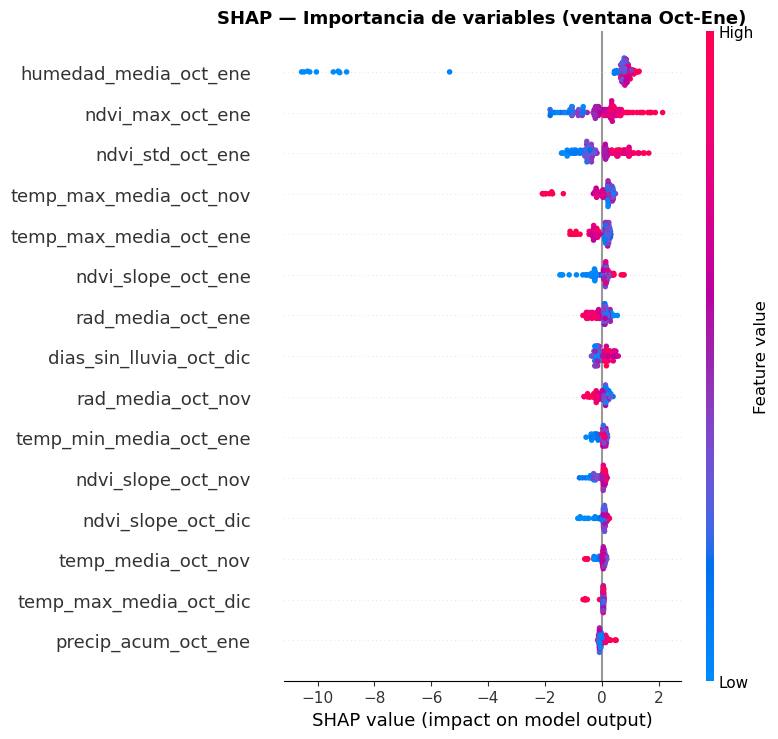

In [7]:
!pip install shap -q
import shap

# Entrenar modelo final con todos los datos hasta 2024 (ventana oct_ene)
features_ene = get_features_ventana("oct_ene")
scaler = StandardScaler()
X_all = scaler.fit_transform(df[features_ene])
y_all = df["rinde_qq_ha"].values

model_final = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
model_final.fit(X_all, y_all)

# SHAP values
explainer = shap.TreeExplainer(model_final)
shap_values = explainer.shap_values(X_all)

# Gráfico de importancia
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_all, feature_names=features_ene, show=False, max_display=15)
plt.title("SHAP — Importancia de variables (ventana Oct-Ene)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Guardar resultados

In [8]:
# Guardar tabla de resultados
output = PROJECT / "outputs"
output.mkdir(parents=True, exist_ok=True)
results_df.to_csv(output / "resultados_modelos.csv", index=False)

# Guardar predicciones de Random Forest oct_ene (para uso futuro)
preds_ene.to_csv(output / "predicciones_rf_oct_ene.csv", index=False)

print("Archivos guardados en outputs/:")
print("  - resultados_modelos.csv")
print("  - predicciones_rf_oct_ene.csv")

Archivos guardados en outputs/:
  - resultados_modelos.csv
  - predicciones_rf_oct_ene.csv
